In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import seaborn as sns
import matplotlib.pyplot as plt
import STAVelo as stv
stv.settings.verbosity = 3
stv.settings.presenter_view = True
stv.set_figure_params("scvelo")
import warnings
warnings.filterwarnings("ignore")

# Read data

In [2]:
adata=sc.read("../data/T2_Mouse_Coronal_Hemibrain_Stereoseq/mousebrain_bin60_clustered.h5ad")
adata.uns["scc_anno_colors"]=np.array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
                                       '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
                                       '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#dbdb8d', '#9edae5'])

# Run model

In [3]:
stv.show_proportions(adata)
adata

Abundance of ['unspliced', 'spliced']: [0.58 0.42]


AnnData object with n_obs × n_vars = 7765 × 21667
    obs: 'area', 'n_counts', 'Size_Factor', 'initial_cell_size', 'louvain', 'scc', 'scc_anno'
    var: 'pass_basic_filter'
    uns: '__type', 'louvain', 'louvain_colors', 'neighbors', 'pp', 'scc', 'scc_anno_colors', 'scc_colors', 'spatial', 'spatial_neighbors'
    obsm: 'X_pca', 'X_spatial', 'bbox', 'contour', 'spatial'
    layers: 'count', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

In [4]:
stv.filter_and_normalize(adata, min_shared_counts=1, n_top_genes=1000)
stv.moments(adata, n_pcs=30, n_neighbors=30)

Filtered out 11064 genes that are detected 1 counts (shared).
Normalized count data: spliced, unspliced.
Extracted 1000 highly variable genes.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [5]:
stv.Cal_Spatial_Net(adata, rad_cutoff=90)

------Calculating spatial graph...
The graph contains 60878 edges, 7765 cells.
7.8401 neighbors per cell on average.


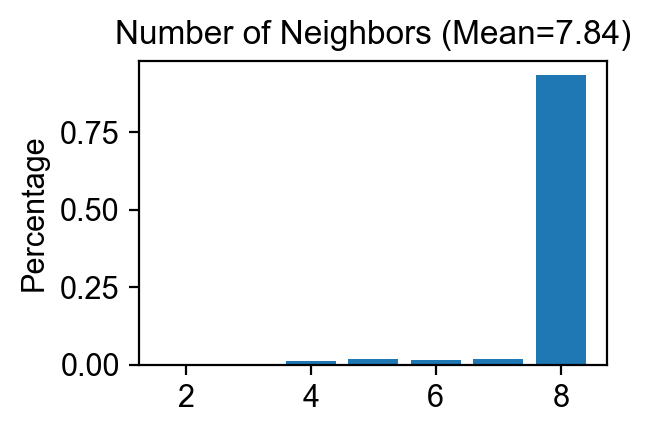

In [6]:
stv.Stats_Spatial_Net(adata)

In [7]:
adata = stv.train_STAVelo(adata, loss_type="cosine", w1 = 1, w2 = 1, random_seed=0, device = 'cuda:1')

Size of Input:  (7765, 1000)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:20<00:00, 49.27it/s]


In [8]:
stv.velocity_graph(adata, n_neighbors=2000, n_jobs=16)

computing velocity graph (using 16/384 cores)


  0%|          | 0/7765 [00:00<?, ?cells/s]

    finished (0:00:20) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Velocity visualization

In [9]:
#adata=sc.read("./result/adata.h5ad")

computing velocity embedding
    finished (0:00:01) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


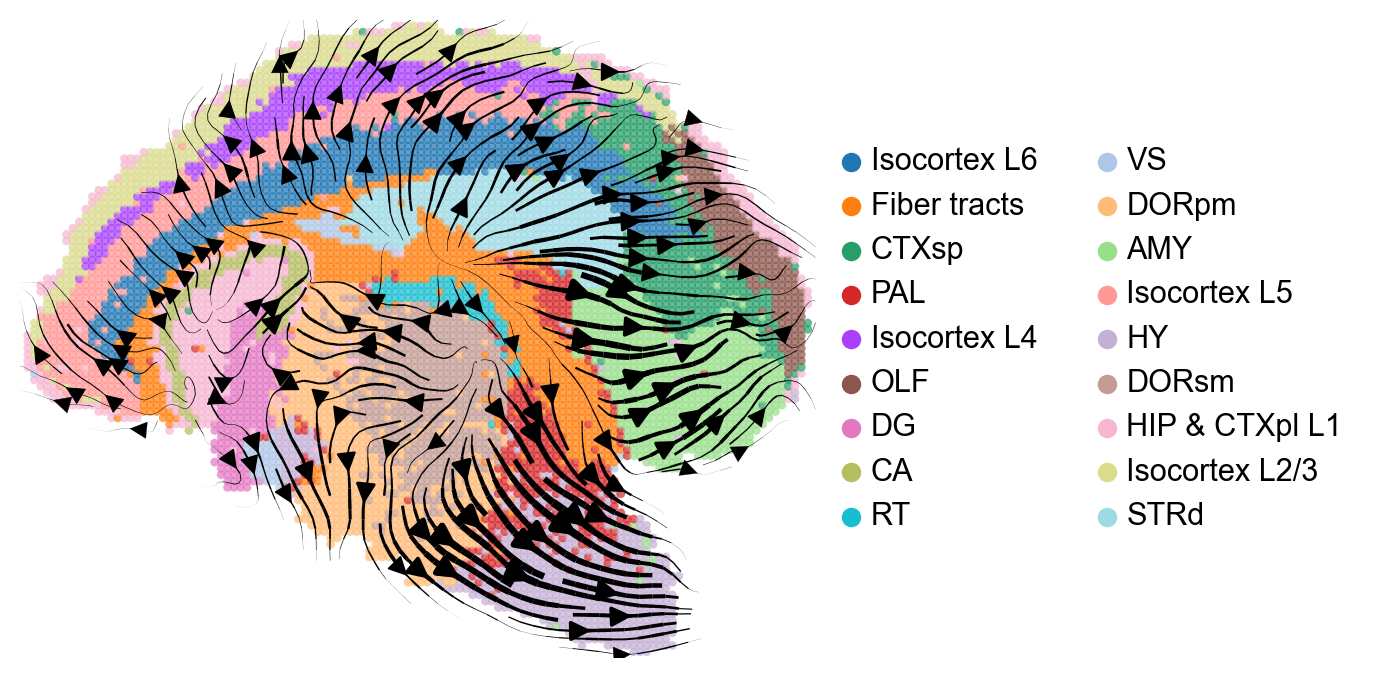

In [10]:
plt.rcParams["figure.figsize"] = (5.1, 4.2)
stv.velocity_embedding_stream(adata, basis='spatial', color="scc_anno", title="", legend_loc="right", alpha=0.7, size=40, 
                              linewidth=1.5, arrow_size=1.5)

In [11]:
#if not os.path.exists("./result"):
#    os.makedirs("./result")
#adata.write("./result/adata.h5ad")